Homework 3, problem 4, part b

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

In [2]:
def capture_lamb(N, T):
    # N = number of lions, T = number of steps or time
    
    animals = {
        # animal: position
        'lamb': [0],
        'lions': [0] * N
    }
    
    # set lions' positions to 10
    for i in range(0, N):
        animals['lions'][i] = 10
    
    # check whether the lamb occupies the same site as any lion
    for time in range(1, T + 1):
        
        # move lamb
        animals['lamb'][0] += random.choice([-1, 1])
        
        # move lions
        for i in range(0, N):
            animals['lions'][i] += random.choice([-1, 1])
        
        for i in range(0, N):
            if animals['lamb'][0] == animals['lions'][i]:
                return time

    return T + 1

In [3]:
def simulate(N, T, R):
    capture_times = []
    
    for i in range(0, R):
        capture_time = capture_lamb(N, T)
        capture_times.append(capture_time)
        
    return capture_times

In [4]:
N = 1
T = 10000
R = 20000

capture_times = simulate(N, T, R)
S_vals = []

for t in range(T):
    count = 0
    
    for time in capture_times:
        if time > t:
            count += 1
        
    S_t = count / R
    S_vals.append(S_t)

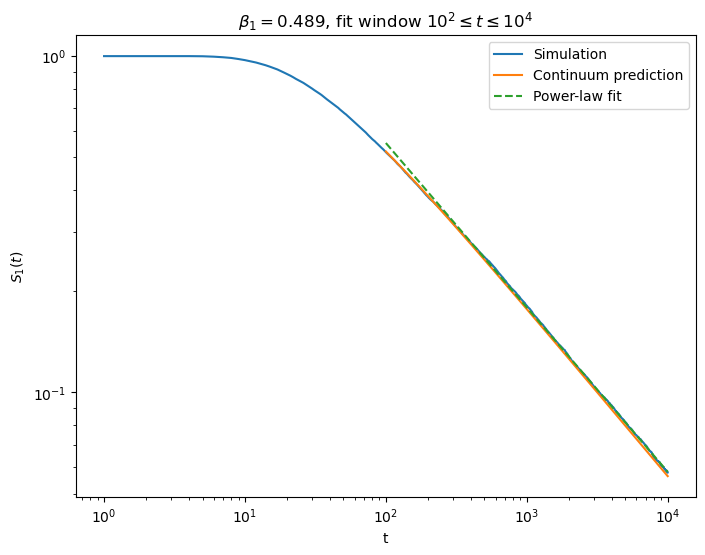

In [5]:
times = np.arange(T)
fit_mask = (times >= 100) & (times <= 10_000)

t_fit = times[fit_mask]
S_fit = np.array(S_vals)[fit_mask]

# log-log linear fit
slope, intercept = np.polyfit(np.log(t_fit), np.log(S_fit), 1)

# beta_1 is the negative of the slope
beta_1 = -slope

d0 = 10
S_continuum = erf(d0 / (2 * np.sqrt(t_fit)))

plt.figure(figsize=(8, 6))

plt.loglog(times[1:], S_vals[1:], label = "Simulation")
plt.loglog(t_fit, S_continuum, label = "Continuum prediction")

S_fit_line = np.exp(intercept) * t_fit ** slope
plt.loglog(t_fit, S_fit_line, '--', label = "Power-law fit")

plt.xlabel("t")
plt.ylabel(r"$S_1(t)$")
plt.title(rf"$\beta_1 = {beta_1:.3f}$, fit window $10^2 \leq t \leq 10^4$")
plt.legend()

plt.show()

Homework 3, problem 4, part c

In [8]:
# N = 2 simulation

N = 1
T = 10_000
R = 20_000

S_vals = []
capture_times = simulate(N, T, R)

for t in range(T + 1):
    count = 0
    
    for time in capture_times:
        if time > t:
            count += 1
    
    S_t = count / R
    S_vals.append(S_t)

N = 2
S2_vals = []
capture_times_2 = simulate(N, T, R)

for t in range(T+1):
    count = 0

    for time in capture_times_2:
        if time > t:
            count += 1

    S_t = count / R
    S2_vals.append(S_t)

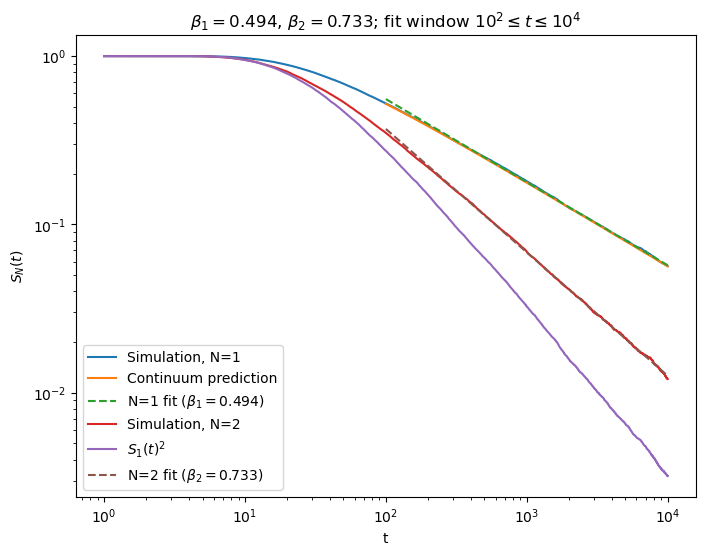

In [10]:
times = np.arange(T + 1)
fit_mask = (times >= 100) & (times <= 10_000)

t_fit = times[fit_mask]
S_fit = np.array(S_vals)[fit_mask]
S2_fit = np.array(S2_vals)[fit_mask]

# log-log linear fits
slope, intercept = np.polyfit(np.log(t_fit), np.log(S_fit), 1)
slope2, intercept2 = np.polyfit(np.log(t_fit), np.log(S2_fit), 1)

# beta is the negative of the slope
beta_1 = -slope
beta_2 = -slope2

# continuum prediction for N = 1
d0 = 10
S_continuum = erf(d0 / (2 * np.sqrt(t_fit)))

# S1(t)^2 prediction for two independent lions
S1_squared = np.array(S_vals) ** 2

# power-law fit lines
S_fit_line = np.exp(intercept) * t_fit ** slope
S2_fit_line = np.exp(intercept2) * t_fit ** slope2

# plotting everything
plt.figure(figsize=(8, 6))

# N = 1 simulation
plt.loglog(times[1:], S_vals[1:], label="Simulation, N=1")

# continuum prediction
plt.loglog(t_fit, S_continuum, label="Continuum prediction")

# N = 1 power-law fit
plt.loglog(
    t_fit,
    S_fit_line,
    '--',
    label=rf"N=1 fit ($\beta_1={beta_1:.3f}$)"
)

# N = 2 simulation
plt.loglog(times[1:], S2_vals[1:], label="Simulation, N=2")

# S1(t)^2
plt.loglog(
    times[1:],
    S1_squared[1:],
    label=r"$S_1(t)^2$"
)

# N = 2 power-law fit
plt.loglog(
    t_fit,
    S2_fit_line,
    '--',
    label=rf"N=2 fit ($\beta_2={beta_2:.3f}$)"
)

plt.xlabel("t")
plt.ylabel(r"$S_N(t)$")
plt.title(
    rf"$\beta_1={beta_1:.3f}$, $\beta_2={beta_2:.3f}$; "
    r"fit window $10^2 \leq t \leq 10^4$"
)
plt.legend()

plt.show()